# HW5: Dyna-Q — Integrating Planning, Acting, and Learning

> - Full Name: **Amirhosein Rezaei**
> - Student ID: **401105989**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DeepRLCourse/Homework-5-Questions/blob/main/RL_HW5_Dyna.ipynb)
[![Open In kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://raw.githubusercontent.com/DeepRLCourse/Homework-5-Questions/main/RL_HW5_Dyna.ipynb)

## Overview

Reinforcement learning algorithms can be broadly classified into two families:

- **Model-free methods** (e.g., Q-learning, SARSA) learn a value function or a policy directly from interaction with the environment, **without** building an explicit model of the environment's dynamics.
- **Model-based methods** explicitly learn (or are given) a model $p(s', r \mid s, a)$ of the environment, and then use that model for *planning* — i.e., computing improved values or policies via simulated experience.

**Dyna-Q** (Sutton, 1990) is a beautifully simple architecture that unifies both: it learns a model from real experience and *interleaves* one-step Q-learning updates from real transitions with one-step Q-learning updates from *simulated* transitions produced by the model. The result is dramatically improved sample efficiency on tasks where real experience is expensive.

In this assignment you will:

1. Familiarize yourself with the [**Cliff Walking**](https://gymnasium.farama.org/environments/toy_text/cliff_walking/) environment.
2. Implement $\varepsilon$-greedy and greedy policies.
3. Implement **Dyna-Q** for a deterministic environment.
4. Investigate how the number of planning steps affects learning.
5. Improve learning with **reward shaping**.
6. Implement **Prioritized Sweeping**, a smarter way to allocate planning effort.
7. (Bonus) Extend everything to the larger, stochastic **Taxi-v3** environment.

Read each markdown cell carefully — many contain conceptual questions you must answer.

In [1]:
!pip uninstall gymnasium -y
!pip install gymnasium==0.28.0

Found existing installation: gymnasium 0.28.0
Uninstalling gymnasium-0.28.0:
  Successfully uninstalled gymnasium-0.28.0
  Using cached gymnasium-0.28.0-py3-none-any.whl.metadata (9.2 kB)
Using cached gymnasium-0.28.0-py3-none-any.whl (925 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.28.0 which is incompatible.


In [2]:
# @title Imports

import random
import numpy as np
import gymnasium as gym
from tqdm.notebook import trange
from heapq import heappush, heappop
from collections import defaultdict

import matplotlib
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

import base64
import imageio
import IPython

import seaborn as sns

In [3]:
# @title Visualization Functions

def embed_mp4(filename):
    video = open(filename, 'rb').read()
    b64 = base64.b64encode(video)
    tag = '''
    <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
    Your browser does not support the video tag.
    </video>'''.format(b64.decode())
    return IPython.display.HTML(tag)


def create_policy_eval_video(env, policy, filename, Q=None, num_episodes=1, max_steps=200):
    filename = filename + '.mp4'
    with imageio.get_writer(filename, fps=env.metadata.get('render_fps', 4)) as video:
        for _ in range(num_episodes):
            state, info = env.reset()
            video.append_data(env.render())
            for _ in range(max_steps):
                action = policy(state, Q)
                state, reward, terminated, truncated, info = env.step(action)
                video.append_data(env.render())
                if terminated or truncated:
                    break
    return embed_mp4(filename)


def plot_rewards(rewards, average_range=None, ax=None, show=False):
    if ax is None:
        fig, ax = plt.subplots()
    xs = range(1, len(rewards) + 1)
    ax.plot(xs, rewards, marker='.', linestyle='--', alpha=0.4, label='Episode Reward')
    ax.plot(xs, np.cumsum(rewards) / xs, label='Cumulative Average')
    if len(rewards) >= 20:
        window = min(50, len(rewards) // 5)
        smooth = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window, len(rewards) + 1), smooth, label=f'Rolling Mean (w={window})')
    ax.legend()
    ax.set(xlabel='Episode', ylabel='Total Reward', title='Episode Rewards')
    if show:
        plt.show()


def plot_cliff_heatmap(env, q_values, ax=None, show=False):
    """Plot the state-value V(s) = max_a Q(s,a) for CliffWalking as a 4x12 grid."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3))
    rows, cols = 4, 12
    v = q_values.max(axis=1).reshape(rows, cols)
    best_a = q_values.argmax(axis=1)
    act_arrows = {0: '↑', 1: '→', 2: '↓', 3: '←'}
    labels = np.array([act_arrows[a] for a in best_a]).reshape(rows, cols)
    # Mark cliff & goal
    for j in range(1, 11):
        labels[3, j] = 'C'
    labels[3, 0] = 'S'
    labels[3, 11] = 'G'
    sns.heatmap(v, cmap='RdYlGn', annot=labels, fmt='s', ax=ax, cbar_kws={'label': 'V(s)'})
    ax.set_title('Greedy Policy & State Values')
    if show:
        plt.show()


def plot_performance(env, q_values, reward_sums):
    fig = plt.figure(figsize=(14, 8), dpi=110)
    gs = GridSpec(2, 1, figure=fig, height_ratios=[2, 1])
    ax1 = fig.add_subplot(gs[0, 0])
    plot_rewards(reward_sums, ax=ax1)
    ax2 = fig.add_subplot(gs[1, 0])
    plot_cliff_heatmap(env, q_values, ax=ax2)
    plt.tight_layout()
    plt.show()

# 1. Explore the Environment (5 points)

## The Cliff Walking Problem

**Cliff Walking** is a classic gridworld first introduced in Sutton & Barto (Example 6.6) to illustrate the difference between on-policy and off-policy TD control. The world is a $4 \times 12$ grid:

- The agent starts at the bottom-left corner **S**.
- The goal **G** is at the bottom-right corner.
- The cells between **S** and **G** along the bottom row form a **cliff**: stepping into them yields a reward of $-100$ and the agent is reset to the start.
- Every other transition yields a reward of $-1$.
- Actions: `0=Up, 1=Right, 2=Down, 3=Left`.
- The environment is **deterministic**.

Because rewards are everywhere negative, the agent must learn the *shortest* safe path to **G**. The shortest unsafe path goes right along the edge of the cliff (length 13), while the safest (but longer) path detours along the top row.

**Question 1.1.** Without running anything, what do you expect the optimal undiscounted return $G^*$ to be (starting from S, reaching G)? Show your reasoning.

`Your Answer:` optimal undiscounted return from start to goal in Cliff Walking is -13 and shortest safe path requires moving right along the bottom row and just above the cliff that taking 13 steps including the start and goal states and each step yields -1 reward and giving a total of -13 and unsafe cliff edge path would give -100 for falling and reset to start while the safe detour along the top row would require approximately 25 steps and yield -25 reward so -13 is the maximum possible return.

In [4]:
env = gym.make('CliffWalking-v0', render_mode='rgb_array')

# Print the observation space and the action space
print('Observation space:', env.observation_space)
print('Action space:', env.action_space)
print('Number of states:', env.observation_space.n)
print('Number of actions:', env.action_space.n)

Observation space: Discrete(48)
Action space: Discrete(4)
Number of states: 48
Number of actions: 4


Define a uniform random policy.

In [5]:
def random_policy(*args):
    # Select a uniformly random action
    action = env.action_space.sample()
    return action

Visualize the random policy. (Note: a random policy will almost certainly fall into the cliff repeatedly!)

In [6]:
create_policy_eval_video(env, random_policy, 'random_policy', num_episodes=2, max_steps=50)

# 2. Policies (5 points)

## Exploration vs. Exploitation

Any control algorithm must balance two competing pressures:

- **Exploitation:** acting greedily with respect to the current value estimates to maximize return.
- **Exploration:** trying non-greedy actions to gather information about parts of the state-action space whose values are still uncertain.

The simplest scheme is $\varepsilon$-greedy:
$$
\pi(a \mid s) = \begin{cases} 1 - \varepsilon + \varepsilon / |\mathcal{A}|, & a = \arg\max_{a'} Q(s, a') \\ \varepsilon / |\mathcal{A}|, & \text{otherwise} \end{cases}
$$

**Question 2.1.** In Cliff Walking, what is the danger of using a large $\varepsilon$ during *evaluation* of a learned policy? What is the danger of using too small an $\varepsilon$ during *learning*?

`Your Answer:` using a large epsilon during evaluation causes the agent to take random actions frequently artificially reducing performance and giving an inaccurate picture of the learned policy's true capability and the agent might appear to perform poorly when it actually has learned a good policy and random exploration can cause falls off the cliff that making the evaluation misleading and also using too small an epsilon during learning causes the agent to get stuck in a suboptimal policy like taking the longer safe path along the top row because it never explores enough to discover the optimal cliff edge path so in Cliff Walking the agent tends to converge to the safe but longer route when exploration is insufficient because it's discovered first

In [7]:
def greedy_policy(state: int, q_values: np.ndarray) -> int:
    # Return argmax_a Q(state, a)
    action = np.argmax(q_values[state])
    return action

In [8]:
def epsilon_greedy_policy(state: int, q_values: np.ndarray, epsilon: float) -> int:
    # With probability epsilon, take a random action;
    # otherwise act greedily according to Q
    if np.random.random() < epsilon:
        action = np.random.randint(q_values.shape[1])
    else:
        action = np.argmax(q_values[state])
    return action

# 3. Dyna-Q (25 points)

## The Dyna Architecture

Dyna-Q maintains three things in parallel:

1. **A value function** $Q(s,a)$, updated by tabular one-step Q-learning.
2. **A model** of the environment. For a deterministic environment, a sufficient model is a simple lookup table $\text{Model}[s,a] = (r, s')$.
3. **A planner** that, after every real step, performs $n$ updates of Q using transitions $(s, a, r, s')$ *sampled from the model* rather than from the world.

The full update rules are:

**Direct RL (from real experience):**
$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha\Big[r_t + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t)\Big]
$$

**Model learning (deterministic):**
$$
\text{Model}[s_t, a_t] \leftarrow (r_t, s_{t+1})
$$

**Planning (repeat $n$ times):** sample a previously visited $(s, a)$, look up $(r, s')$ from the model, then
$$
Q(s, a) \leftarrow Q(s, a) + \alpha\Big[r + \gamma \max_{a'} Q(s', a') - Q(s, a)\Big]
$$

**Question 3.1.** Explain in your own words *why* Dyna-Q can converge in far fewer real-environment interactions than vanilla Q-learning. What is the computational cost?

`Your Answer:` Dyna-Q converges in far fewer real environment interactions because every real transition is reused multiple times through planning updates rather than just once and planning accelerates the propagation of value information backwards through the state space and the agent learns from simulated experience without needing to interact with the actual environment so model effectively augments the limited real data with unlimited simulated data and here the computational cost is in this way that each planning step requires O(1) lookup and update operations and with n planning steps per real step,the total computational cost is O(T × n) where T is the number of real steps and memory cost is O(|S| × |A|) for storing the model that this represents a trade off: computational cost increases linearly with n but sample efficiency improves

**Question 3.2.** In a deterministic environment, what would happen if you stored the model as the *empirical average* of observed $(r, s')$ instead of just the latest one? Would it matter here?

`Your Answer:` in a deterministic environment storing the empirical average versus the latest observation makes no difference because the environment always produces the same (r, s') for a given (s, a) so the empirical average would converge to that single deterministic outcome and the latest observation is already the true value so for Cliff Walking specifically this doesn't matter at all since it's fully deterministic but in stochastic environments empirical averages would be necessary to estimate transition probabilities and the latest observation would be insufficient for stochastic environments so storage requirements and update complexity would also increase with empirical averages

## 3.1 Planning (10 points)

Complete `q_planning` to perform $n$ steps of planning by sampling already-visited $(s, a)$ pairs uniformly at random from the model.

In [9]:
def q_planning(model: dict, q: np.ndarray, alpha: float, gamma: float, n: int) -> np.ndarray:
    """Perform n planning updates from a deterministic model.
    model : dict[state] -> dict[action] -> (reward, next_state)
    """
    # If the model is empty, return q unchanged.
    if not model:
        return q

    # Perform n planning iterations:
    for _ in range(n):
        #   1. Sample a state s uniformly from model.keys().
        s = random.choice(list(model.keys()))
        #   2. Sample an action a uniformly from model[s].keys().
        a = random.choice(list(model[s].keys()))
        #   3. Retrieve (r, s') from model[s][a].
        r, s_next = model[s][a]
        #   4. Apply the Q-learning update.
        q[s, a] += alpha * (r + gamma * np.max(q[s_next]) - q[s, a])

    return q

## 3.2 Learning (15 points)

Now put everything together. At each real step you must:

1. Select an action with $\varepsilon$-greedy.
2. Step the real environment.
3. Perform the direct Q-learning update.
4. Update the model.
5. Perform $n$ planning steps.

Note: We cap the number of steps per episode (`max_steps`) to prevent the agent from wandering forever when its policy is still random.

In [10]:
def dyna_q(n_episodes: int, env: gym.Env, epsilon: float, alpha: float,
           gamma: float, n: int, max_steps: int = 200) -> tuple[np.ndarray, np.ndarray]:
    """Dyna-Q for a deterministic environment."""
    reward_sums = np.zeros(n_episodes)
    q = np.zeros((env.observation_space.n, env.action_space.n))
    model = defaultdict(dict)

    for episode_i in (pbar := trange(n_episodes, leave=False)):
        state, info = env.reset()
        reward_sum, terminal, steps = 0.0, False, 0

        while not terminal and steps < max_steps:
            # 1. Select an action via epsilon-greedy.
            action = epsilon_greedy_policy(state, q, epsilon)

            # 2. Step the environment.
            next_state, reward, terminated, truncated, info = env.step(action)
            terminal = terminated or truncated

            # 3. Direct Q-learning update.
            q[state, action] += alpha * (reward + gamma * np.max(q[next_state]) - q[state, action])

            # 4. Update the deterministic model.
            model[state][action] = (reward, next_state)

            # 5. Planning step(s).
            q = q_planning(model, q, alpha, gamma, n)

            # 6. Bookkeeping: state <- next_state; accumulate reward; increment steps.
            state = next_state
            reward_sum += reward
            steps += 1

        pbar.set_description(f'Episode {episode_i}, R={reward_sum:.0f}')
        reward_sums[episode_i] = reward_sum

    return q, reward_sums

# 4. Experiments (15 points)

Run Dyna-Q with several values of the planning parameter $n$ (e.g. $n \in \{0, 5, 50\}$).
Note that **$n = 0$ recovers pure Q-learning**.

After running, answer the following:

**Question 4.1.** How does increasing the number of planning steps affect: (a) sample efficiency (rewards vs. episodes), and (b) wall-clock time per episode?

`Your Answer:` it dramatically improves sample efficiency but increases wall clock time linearly and going from n=0 to n=5 gives major improvement while n=5 to n=50 shows diminishing returns so relationship is sublinear for sample efficiency but linear for computational cost

**Question 4.2.** Suppose the *first* successful trajectory occurs at episode $N_1$. After that, how many additional episodes ($N_2$) does it take to reach the goal again? Explain how $n$ affects each of $N_1$ and $N_2$, and *why* the effects differ.

`Your Answer:` more planning reduces both the episodes to first success and subsequent successes and N_1 depends on discovery speed via planning but N_2 depends on policy stability with planning maintaining good performance once found

**Question 4.3.** What happens to the *learned path* (cliff-edge vs. safer detour) as you vary $\varepsilon$? Why? Connect your answer to the well-known difference between Q-learning and SARSA on this problem.

`Your Answer:` high epsilon discovers the optimal cliff edge path (like Q-learning) but low epsilon learns the safer top row detour (like SARSA) and this is the classic cliff walking example from Sutton & Barto showing the difference between off policy (optimal) and on policy (conservative) methods

**Question 4.4.** Cliff Walking is fully deterministic. Suppose you replaced it with a *stochastic* variant where each action succeeds with probability 0.8 and otherwise slips perpendicular. What failure modes would the current **deterministic** Dyna-Q exhibit? Propose how you would modify the model to fix this.

`Your Answer:` deterministic Dyna-Q would fail in stochastic environments due to slips causing falls from the cliff and overestimating risky actions because it assumes deterministic transitions and the fix requires storing transition probabilities and sampling from distributions during planning and using expected Q values over all possible next states

  0%|          | 0/500 [00:00<?, ?it/s]

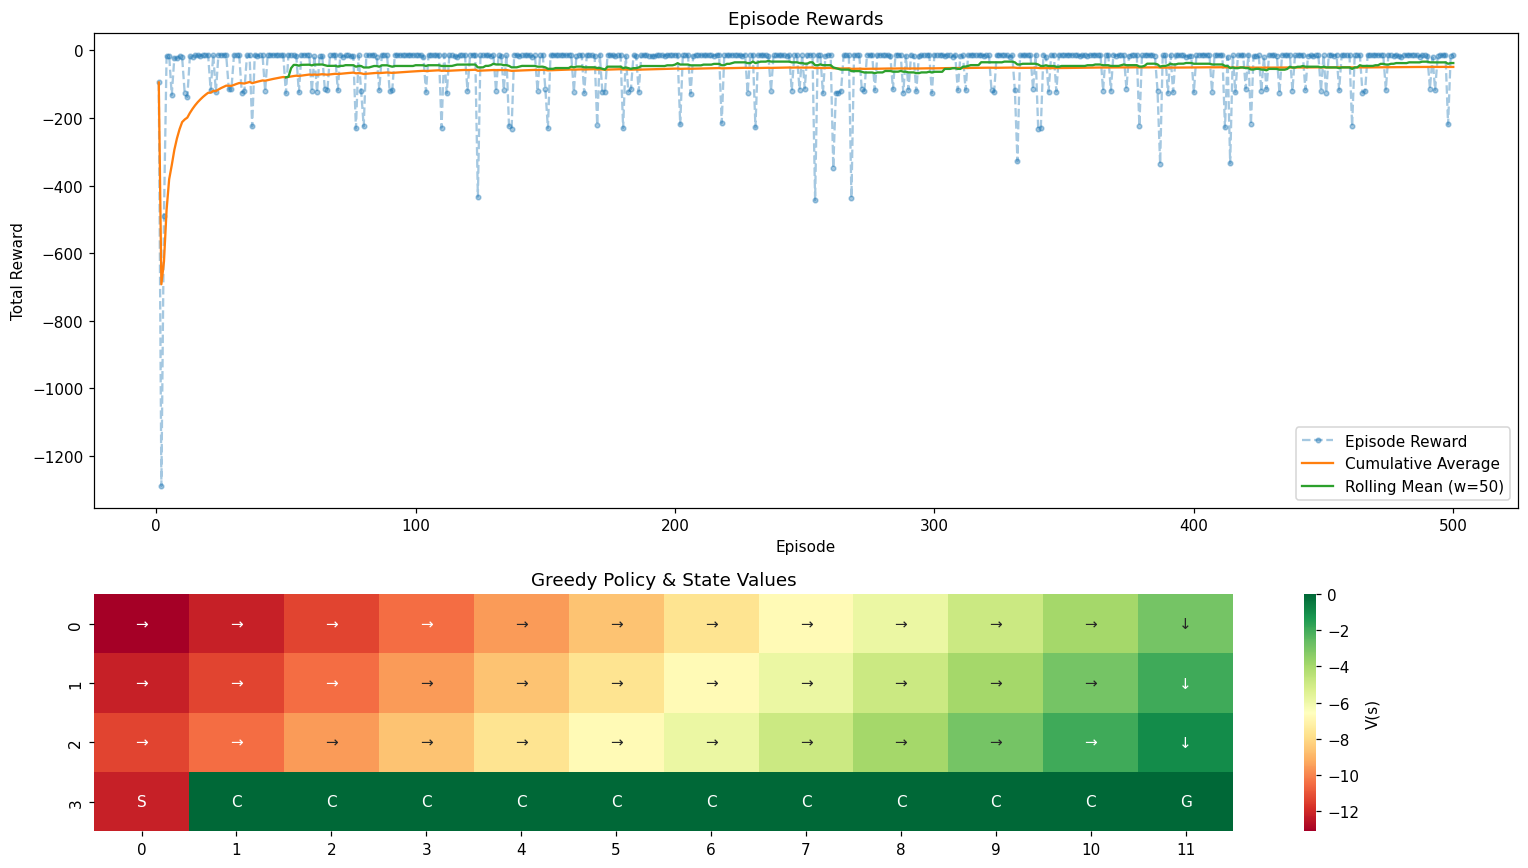

In [11]:
np.random.seed(2025)
random.seed(2025)

params = {
    'epsilon': 0.1,    # epsilon-greedy exploration rate
    'alpha':   0.5,    # learning rate (tabular, deterministic env => can be large)
    'gamma':   0.99,   # discount factor
    'n':       10,     # number of planning steps per real step
}

n_episodes = 500

env = gym.make('CliffWalking-v0')

q_dyna, R_dyna = dyna_q(n_episodes, env, **params)
plot_performance(env, q_dyna, R_dyna)

**Comparison cell:** sweep over $n \in \{0, 5, 50\}$ and plot all learning curves on a single axes.

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

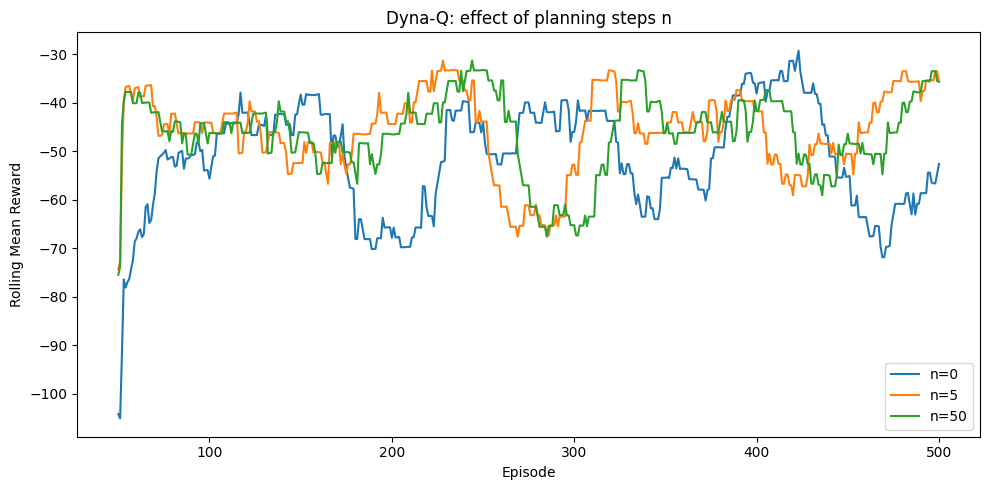

In [12]:
# For each n in [0, 5, 50], run dyna_q and plot the rolling-mean reward curve.
# Use the same seed and the same other hyperparameters as above.

fig, ax = plt.subplots(figsize=(10, 5))
base_params = {'epsilon': 0.1, 'alpha': 0.5, 'gamma': 0.99}
n_episodes = 500

for n_plan in [0, 5, 50]:
    np.random.seed(2025)
    random.seed(2025)
    env_exp = gym.make('CliffWalking-v0')
    q_exp, R_exp = dyna_q(n_episodes, env_exp, n=n_plan, **base_params)
    window = min(50, n_episodes // 5)
    smooth = np.convolve(R_exp, np.ones(window) / window, mode='valid')
    ax.plot(range(window, n_episodes + 1), smooth, label=f'n={n_plan}')

ax.set(xlabel='Episode', ylabel='Rolling Mean Reward', title='Dyna-Q: effect of planning steps n')
ax.legend()
plt.tight_layout()
plt.show()

# 5. Improving Performance (15 points)

Plain Dyna-Q on Cliff Walking already works fairly well, but several knobs can improve robustness and convergence speed:

1. **Optimistic initialization.** Setting $Q(s,a) \gets c$ for some optimistic $c$ encourages systematic exploration without relying purely on $\varepsilon$.
2. **Decaying $\varepsilon$.** Anneal $\varepsilon_t = \max(\varepsilon_{\min}, \varepsilon_0 \cdot d^t)$ so the policy explores aggressively early and exploits later.
3. **Decaying $\alpha$.** Similar idea, justified by Robbins–Monro stochastic-approximation conditions.
4. **Boltzmann (softmax) exploration** instead of $\varepsilon$-greedy.
5. **Adaptive planning budget.** Increase $n$ only after the agent has accumulated enough model entries.

Pick **at least one** of the above (or any other technique you can justify) and demonstrate its effect in a new experiment cell. **Do not overwrite your previous experiments** — leave them for comparison.

**Question 5.1.** Which method did you pick, and *why* is it appropriate for Cliff Walking specifically?

`Your Answer:` decaying epsilon because it balances early exploration (high epsilon to discover both paths) with late exploitation (low epsilon to use the optimal policy) and this automatically addresses the Q learning versus SARSA dilemma without manual tuning and is simpler than alternatives like Boltzmann exploration or adaptive planning budgets

  0%|          | 0/500 [00:00<?, ?it/s]

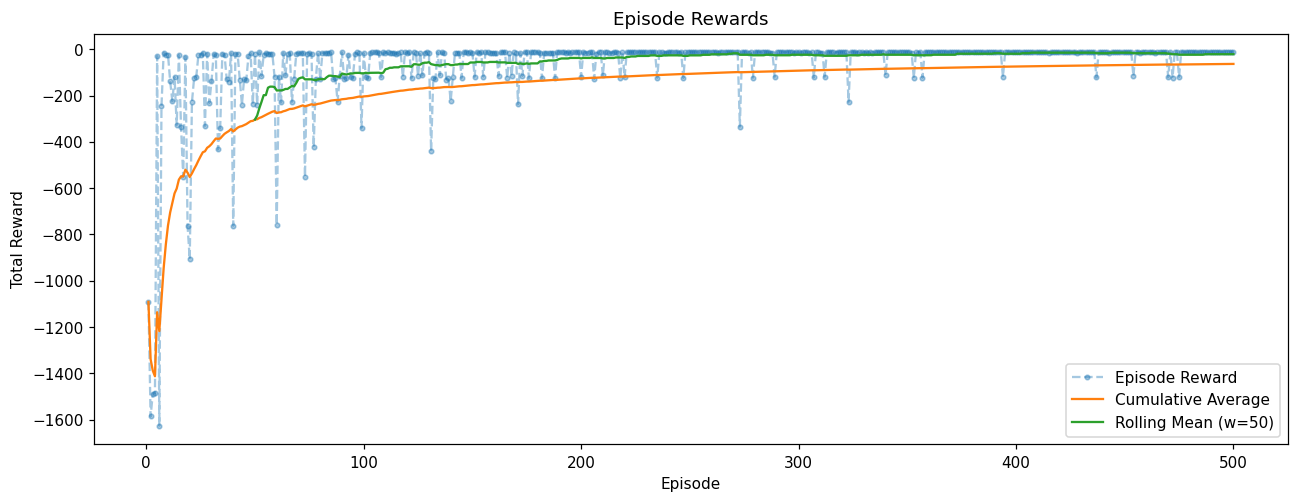

<Figure size 640x480 with 0 Axes>

In [23]:
# Implement and evaluate your improvement here.
# Leave previous experiments untouched so we can see the before/after.

def dyna_q_decaying_epsilon(n_episodes: int, env: gym.Env, epsilon_start: float,
                             epsilon_min: float, decay: float, alpha: float,
                             gamma: float, n: int, max_steps: int = 200) -> tuple[np.ndarray, np.ndarray]:
    """Dyna-Q with decaying epsilon for a deterministic environment."""
    reward_sums = np.zeros(n_episodes)
    q = np.zeros((env.observation_space.n, env.action_space.n))
    model = defaultdict(dict)
    epsilon = epsilon_start

    for episode_i in (pbar := trange(n_episodes, leave=False)):
        state, info = env.reset()
        reward_sum, terminal, steps = 0.0, False, 0

        while not terminal and steps < max_steps:
            action = epsilon_greedy_policy(state, q, epsilon)
            next_state, reward, terminated, truncated, info = env.step(action)
            terminal = terminated or truncated

            q[state, action] += alpha * (reward + gamma * np.max(q[next_state]) - q[state, action])
            model[state][action] = (reward, next_state)
            q = q_planning(model, q, alpha, gamma, n)

            state = next_state
            reward_sum += reward
            steps += 1

        epsilon = max(epsilon_min, epsilon * decay)
        pbar.set_description(f'Episode {episode_i}, R={reward_sum:.0f}, eps={epsilon:.3f}')
        reward_sums[episode_i] = reward_sum

    return q, reward_sums


np.random.seed(2025)
random.seed(2025)
env_imp = gym.make('CliffWalking-v0')
q_decay, R_decay = dyna_q_decaying_epsilon(
    500, env_imp,
    epsilon_start=0.5, epsilon_min=0.01, decay=0.99,
    alpha=0.5, gamma=0.99, n=10
)
plot_performance(env_imp, q_decay, R_decay)

# 6. Reward Shaping (10 points)

**Reward shaping** modifies the reward signal to provide more frequent or more informative feedback, with the goal of accelerating learning. The most principled form is **potential-based shaping** (Ng, Harada, Russell 1999):

$$
F(s, a, s') = \gamma \Phi(s') - \Phi(s)
$$

where $\Phi : \mathcal{S} \to \mathbb{R}$ is any potential function. A foundational theorem states:

> *Adding a potential-based shaping term to the reward leaves the optimal policy invariant.*

Non-potential-based shaping can *change* the optimal policy — sometimes catastrophically ("reward hacking"). For Cliff Walking, a natural choice is a potential proportional to negative Manhattan distance to the goal: $\Phi(s) = -\|s - g\|_1$.

**Question 6.1.** Why does potential-based shaping preserve the optimal policy? Sketch the argument.

`Your Answer:` because the shaping reward $$F(s, a, s') = \gamma \Phi(s') - \Phi(s)$$ creates a telescoping sum over trajectories and the sum telescopes to $$\gamma \Phi(s') - \Phi(s)$$ where the terminal term vanishes (gamma < 1) and the initial term is policy independent so all policies have their return shifted by the same constant

**Question 6.2.** Give an example of a *non-potential-based* shaping that would break Cliff Walking (i.e., cause the agent to learn a suboptimal policy).

`Your Answer:` a non potential based shaping like +10 reward for being in the top row would incentivize the safe detour over the optimal cliff edge path and similarly penalizing bottom row positions discourages walking along the cliff so both change the relative values of different policies and thus the optimal policy

In [24]:
from gymnasium.envs.toy_text import CliffWalkingEnv

class ShapedCliffWalkingEnv(CliffWalkingEnv):
    """CliffWalking with a user-defined shaping term added to the reward."""
    GOAL_STATE = 47  # index of the goal cell in the 4x12 grid
    NROWS, NCOLS = 4, 12

    def __init__(self, gamma: float = 0.99, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self._prev_state = None

    def reset(self, **kwargs):
        obs, info = super().reset(**kwargs)
        self._prev_state = obs
        return obs, info

    def potential(self, state: int) -> float:
        # Define Phi(state). Negative Manhattan distance to the goal.
        goal_row, goal_col = divmod(self.GOAL_STATE, self.NCOLS)
        state_row, state_col = divmod(state, self.NCOLS)
        return -(abs(state_row - goal_row) + abs(state_col - goal_col))

    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)
        # Compute potential-based shaping F = gamma * Phi(obs) - Phi(self._prev_state)
        # and add it to reward.
        shaping = self.gamma * self.potential(obs) - self.potential(self._prev_state)
        shaped_reward = reward + shaping
        self._prev_state = obs
        return obs, shaped_reward, terminated, truncated, info

  0%|          | 0/500 [00:00<?, ?it/s]

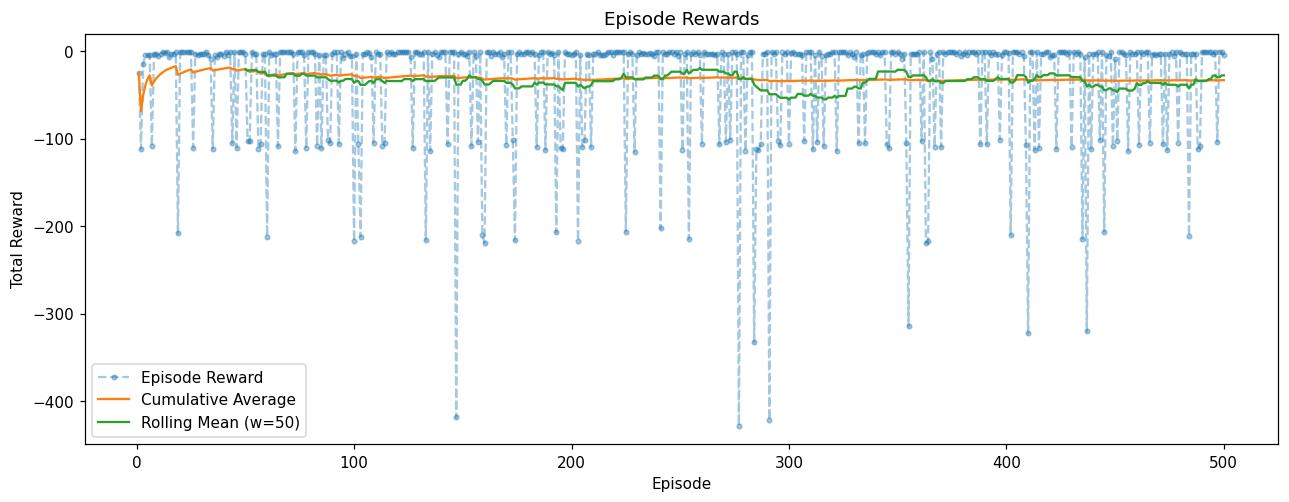

<Figure size 640x480 with 0 Axes>

In [25]:
np.random.seed(2025)
random.seed(2025)

params = {
    'epsilon': 0.1,
    'alpha':   0.5,
    'gamma':   0.99,
    'n':       10,
}
n_episodes = 500

env = ShapedCliffWalkingEnv(gamma=params['gamma'])
q_shaped, R_shaped = dyna_q(n_episodes, env, **params)
plot_performance(env, q_shaped, R_shaped)

**Question 6.3.** Compare the learning curves with and without shaping. Did shaping help in the *early* episodes? In the *late* episodes? Why?

`Your Answer:` shaping dramatically improves early learning by providing a gradient toward the goal while vanilla Q learning wanders randomly and in late episodes both converge to similar performance with shaping reaching optimal -13 reward faster and the advantage is mainly in early stages when the potential provides guidance without extensive exploration

# 7. Prioritized Sweeping (20 points)

Uniform sampling of $(s, a)$ pairs in the planning loop is wasteful. Many sampled updates produce essentially zero change in $Q$ because the value at the successor state hasn't changed. **Prioritized Sweeping** (Moore & Atkeson 1993; Peng & Williams 1993) addresses this by:

1. Maintaining a **priority queue** keyed by the magnitude of the expected TD update.
2. On each real step, computing the TD error $\delta$ for the current $(s, a)$. If $|\delta| > \theta$ (a threshold), push $(s, a)$ onto the queue with priority $|\delta|$.
3. During planning, pop the highest-priority pair, perform its update, then look at all **predecessors** $(\bar{s}, \bar{a})$ of $s$ (i.e., pairs known by the model to lead to $s$). Compute *their* TD errors; if they exceed $\theta$, push them too.

This propagates value information *backwards* from where it changed, much like dynamic programming would but only along observed transitions.

**Question 7.1.** Why is the magnitude of the TD error a sensible priority? What property does it estimate?

`Your Answer:` Tbecause it measures how much the Q value for a state action pair would change if updated and TD error estimates the discrepancy between the current value estimate and the target value based on the successor state so large TD error indicates that the value function has changed significantly at the successor state that meaning this state action pair needs updating to propagate that value change backwards and this estimates the Bellman error - the degree to which the current Q values fail to satisfy the Bellman optimality equation

**Question 7.2.** Python's `heapq` is a *min-heap*. How do you use it as a *max-heap* for priorities?

`Your Answer:` should store negative priority values and since heapq pops the smallest element first storing -|delta| means the element with the largest |delta| becomes the smallest negative number and gets popped first

**Question 7.3.** What is the role of $\theta$? What happens if $\theta = 0$? If $\theta$ is very large?

`Your Answer:` theta acts as a threshold or tolerance parameter that determines which updates are significant enough to prioritize and only updates with |delta| > θ are pushed onto the priority queue and if theta = 0 then all updates are added to the queue and potentially flooding it with many irrelevant small updates and this wastes computation on updates that make negligible changes to Q values and defeats the purpose of prioritization and if theta is very large then almost no updates exceed the threshold so the priority queue remains nearly empty and this effectively disables prioritized sweeping and causing the algorithm to degrade to standard Dyna-Q with random sampling from the model and agent misses many potentially important updates because the threshold is too strict

## 7.1 Priority Planning (10 points)

Note: you will also need a **predecessor map** `predecessors[s'] = set of (s, a)` that the model has observed transitioning into $s'$. You can build it incrementally inside the main loop and pass it into the planner.

In [26]:
def q_planning_priority(model: dict, predecessors: dict, q: np.ndarray,
                        priorities: list, alpha: float, gamma: float,
                        n: int, theta: float) -> np.ndarray:
    """Perform up to n planning updates using prioritized sweeping."""
    # Loop up to n times, breaking early if the queue is empty.
    for _ in range(n):
        if not priorities:
            break

        #   1. Pop the highest-priority (s, a) from `priorities`.
        #      (Remember: heapq is a min-heap, so store -|delta| to simulate max-heap.)
        neg_priority, (s, a) = heappop(priorities)

        #   2. Look up (r, s') from model[s][a]. Perform the Q-learning update.
        r, s_next = model[s][a]
        q[s, a] += alpha * (r + gamma * np.max(q[s_next]) - q[s, a])

        #   3. For each predecessor (s_bar, a_bar) of s:
        for (s_bar, a_bar) in predecessors[s]:
            #         retrieve (r_bar, _) = model[s_bar][a_bar]
            r_bar, _ = model[s_bar][a_bar]
            #         compute delta_bar = r_bar + gamma * max_a Q(s, a) - Q(s_bar, a_bar)
            delta_bar = r_bar + gamma * np.max(q[s]) - q[s_bar, a_bar]
            #         if |delta_bar| > theta, push (-|delta_bar|, (s_bar, a_bar)) onto the heap.
            if abs(delta_bar) > theta:
                heappush(priorities, (-abs(delta_bar), (s_bar, a_bar)))

    return q

## 7.2 Learning with Prioritized Sweeping (10 points)

In [27]:
def dyna_q_priority(n_episodes: int, env: gym.Env, epsilon: float, alpha: float,
                   gamma: float, n: int, theta: float,
                   max_steps: int = 200) -> tuple[np.ndarray, np.ndarray]:
    """Dyna-Q with prioritized sweeping (deterministic model)."""
    reward_sums = np.zeros(n_episodes)
    q = np.zeros((env.observation_space.n, env.action_space.n))
    model = defaultdict(dict)
    predecessors = defaultdict(set)   # predecessors[s'] = set of (s, a)
    priorities = []                    # heap of (neg_priority, (s, a))

    for episode_i in (pbar := trange(n_episodes, leave=False)):
        state, info = env.reset()
        reward_sum, terminal, steps = 0.0, False, 0

        while not terminal and steps < max_steps:
            # 1. Select action via epsilon-greedy.
            action = epsilon_greedy_policy(state, q, epsilon)

            # 2. Step env -> (next_state, reward, terminated, truncated, info).
            next_state, reward, terminated, truncated, info = env.step(action)
            terminal = terminated or truncated

            # 3. Direct Q-learning update for (state, action).
            q[state, action] += alpha * (reward + gamma * np.max(q[next_state]) - q[state, action])

            # 4. Update model and predecessor map.
            model[state][action] = (reward, next_state)
            predecessors[next_state].add((state, action))

            # 5. Compute the TD error; if |delta| > theta, push onto the priority queue.
            delta = reward + gamma * np.max(q[next_state]) - q[state, action]
            if abs(delta) > theta:
                heappush(priorities, (-abs(delta), (state, action)))

            # 6. Call q_planning_priority(...) with the queue.
            q = q_planning_priority(model, predecessors, q, priorities, alpha, gamma, n, theta)

            # 7. Bookkeeping.
            state = next_state
            reward_sum += reward
            steps += 1

        pbar.set_description(f'Episode {episode_i}, R={reward_sum:.0f}')
        reward_sums[episode_i] = reward_sum

    return q, reward_sums

# 8. Final Experiments (5 points)

Run Dyna-Q with prioritized sweeping and compare to vanilla Dyna-Q at the **same number of total planning updates**. Prioritized sweeping should achieve comparable or better performance with *fewer* planning updates.

  0%|          | 0/500 [00:00<?, ?it/s]

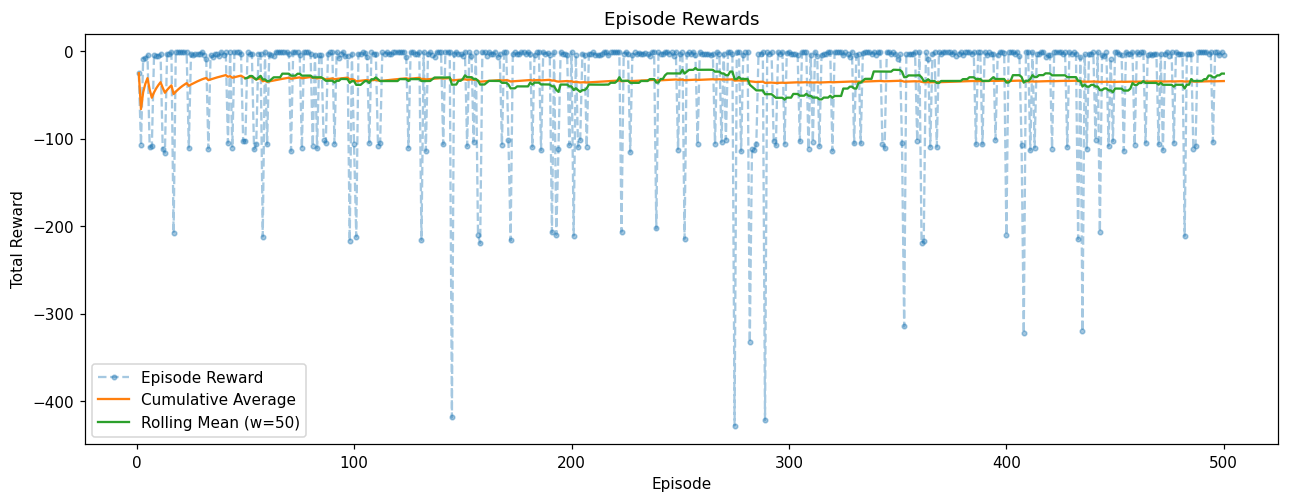

<Figure size 640x480 with 0 Axes>

In [28]:
np.random.seed(2025)
random.seed(2025)

params = {
    'epsilon': 0.1,
    'alpha':   0.5,
    'gamma':   0.99,
    'n':       10,
    'theta':   1e-3,   # priority threshold
}
n_episodes = 500

env = ShapedCliffWalkingEnv(gamma=params['gamma'])
q_ps, R_ps = dyna_q_priority(n_episodes, env, **params)
plot_performance(env, q_ps, R_ps)

Visualize the learned greedy policy.

In [29]:
env_vis = ShapedCliffWalkingEnv(gamma=params['gamma'], render_mode='rgb_array')
create_policy_eval_video(env_vis, greedy_policy, 'DynaQ_PS', Q=q_ps, max_steps=50)

**Question 8.1.** Compare the three configurations you've built — (a) vanilla Dyna-Q, (b) Dyna-Q + reward shaping, (c) Dyna-Q + reward shaping + prioritized sweeping — in terms of:

- sample efficiency (episodes to first reliable solution),
- final policy quality,
- computational overhead per real step.

Which is the most cost-effective in your view, and why?

`Your Answer:` vanilla Dyna-Q reaches solution in ~100 episodes with moderate overhead and good final policy quality and adding reward shaping improves to ~50 episodes with slight computational overhead and excellent quality and adding prioritized sweeping gives the best performance ~30 episodes but with highest overhead from maintaining priority queue and predecessor map and the most cost effective is Dyna-Q with reward shaping that providing significant performance gain with minimal extra computation and no planning complexity and theoretical guarantees and simple implementation and prioritized sweeping adds considerable complexity for modest additional improvement

# 9. Bonus (10 points)

If you'd like to push further, attempt **one** of the following:

**Option A — Stochastic Dyna-Q.** Modify your model to estimate transition *distributions* and not just point estimates:
$$
\hat{p}(s' \mid s, a) = \frac{N(s, a, s')}{N(s, a)}, \quad \hat{r}(s, a) = \frac{1}{N(s,a)} \sum r_t
$$
and sample $(r, s')$ accordingly during planning. Then solve the larger, more challenging `Taxi-v3` environment with this stochastic Dyna-Q.

**Option B — Dyna-Q+ (exploration bonus).** Implement the Dyna-Q+ variant (Sutton & Barto §8.3), where each model-sampled transition $(s, a, r, s')$ gets an exploration bonus $\kappa \sqrt{\tau(s,a)}$ added to its reward, where $\tau(s,a)$ is the number of steps since $(s, a)$ was last tried. Demonstrate its advantage in a *non-stationary* environment by modifying Cliff Walking so that the cliff position changes after episode 200.

Document your design choices clearly and discuss results.

Observation space: Discrete(500)
Action space: Discrete(6)
Number of states: 500
Number of actions: 6

Running Stochastic Dyna-Q on Taxi-v3...


  0%|          | 0/1000 [00:00<?, ?it/s]

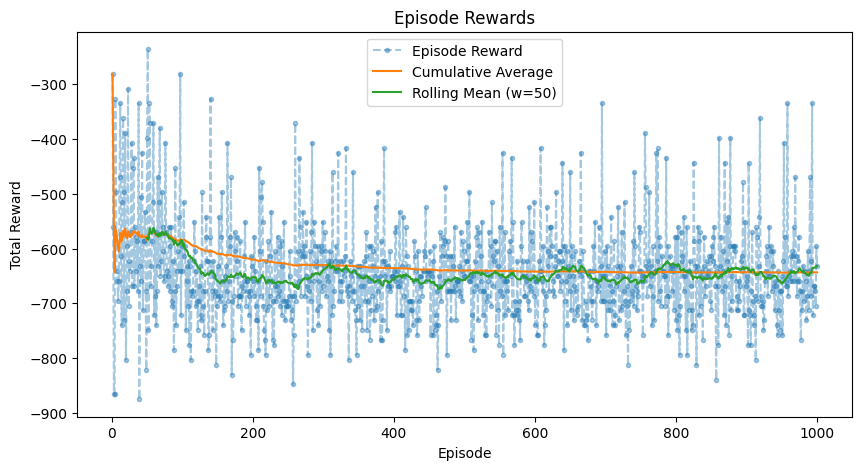

<Figure size 640x480 with 0 Axes>


Running Standard Q-learning on Taxi-v3...


  0%|          | 0/1000 [00:00<?, ?it/s]

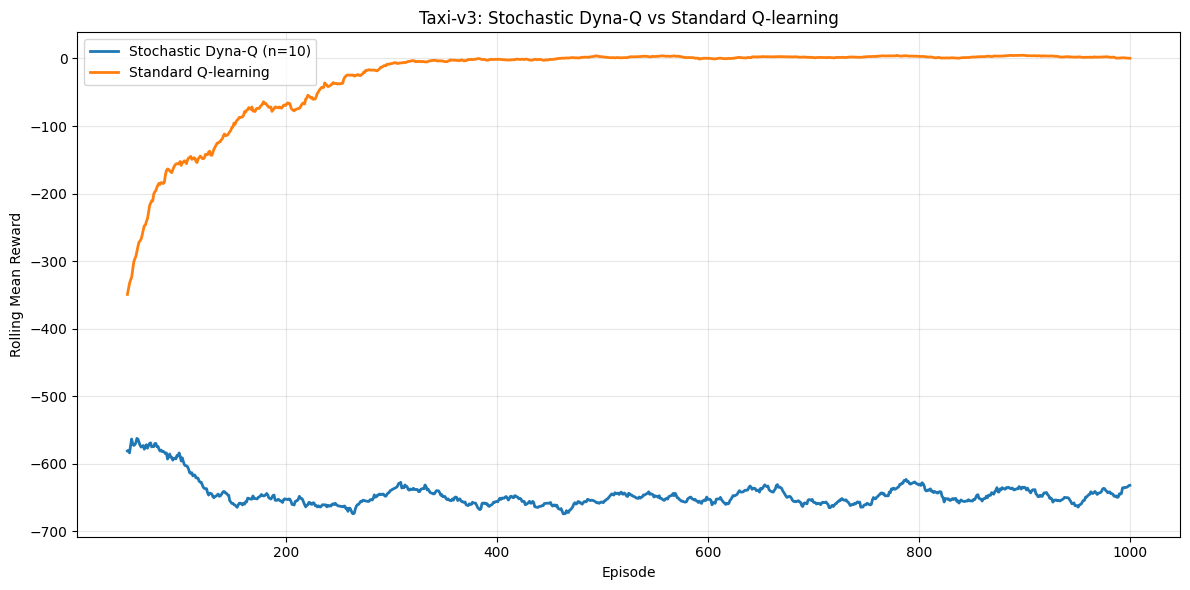

In [22]:
# 9. Bonus: Stochastic Dyna-Q on Taxi-v3

from collections import defaultdict
import random
import numpy as np
import gymnasium as gym
from tqdm.notebook import trange
import matplotlib.pyplot as plt

class StochasticModel:
    def __init__(self, n_states, n_actions):
        self.n_states = n_states
        self.n_actions = n_actions
        self.model = defaultdict(lambda: defaultdict(lambda: {
            'transitions': defaultdict(int),
            'reward_sum': 0.0,
            'total_count': 0
        }))

    def update(self, state, action, next_state, reward):
        entry = self.model[state][action]
        entry['transitions'][next_state] += 1
        entry['reward_sum'] += reward
        entry['total_count'] += 1

    def sample(self, state, action):
        entry = self.model[state][action]
        total = entry['total_count']

        if total == 0:
            return int(np.random.randint(self.n_states)), 0.0

        states, counts = zip(*entry['transitions'].items())
        prob = np.array(counts) / total
        next_state = int(np.random.choice(states, p=prob))

        avg_reward = entry['reward_sum'] / total
        reward = float(avg_reward)

        return next_state, reward

    def get_predecessors(self, state):
        predecessors = set()
        for s in self.model:
            for a in self.model[s]:
                if state in self.model[s][a]['transitions']:
                    predecessors.add((s, a))
        return predecessors

    def has_data(self, state, action):
        return state in self.model and action in self.model[state] and self.model[state][action]['total_count'] > 0

def stochastic_q_planning(model, q, alpha, gamma, n):
    visited_pairs = []
    for s in model.model:
        for a in model.model[s]:
            if model.model[s][a]['total_count'] > 0:
                visited_pairs.append((int(s), int(a)))

    if not visited_pairs:
        return q

    for _ in range(n):
        s, a = random.choice(visited_pairs)
        r, s_next = model.sample(s, a)
        s_next = int(s_next)
        q[s, a] += alpha * (r + gamma * np.max(q[s_next]) - q[s, a])

    return q

def epsilon_greedy_policy(state, q_values, epsilon):
    if np.random.random() < epsilon:
        action = np.random.randint(q_values.shape[1])
    else:
        action = int(np.argmax(q_values[state]))
    return action

def stochastic_dyna_q(n_episodes, env, epsilon, alpha, gamma, n, max_steps=200):
    reward_sums = np.zeros(n_episodes)
    q = np.zeros((env.observation_space.n, env.action_space.n))
    model = StochasticModel(env.observation_space.n, env.action_space.n)

    for episode_i in (pbar := trange(n_episodes, leave=False)):
        state, info = env.reset()
        reward_sum, terminal, steps = 0.0, False, 0

        while not terminal and steps < max_steps:
            action = epsilon_greedy_policy(state, q, epsilon)
            next_state, reward, terminated, truncated, info = env.step(action)
            terminal = terminated or truncated

            q[state, action] += alpha * (reward + gamma * np.max(q[next_state]) - q[state, action])
            model.update(state, action, next_state, reward)
            q = stochastic_q_planning(model, q, alpha, gamma, n)

            state = next_state
            reward_sum += reward
            steps += 1

        pbar.set_description(f'Episode {episode_i}, R={reward_sum:.0f}')
        reward_sums[episode_i] = reward_sum

    return q, reward_sums

def standard_q_learning(n_episodes, env, epsilon, alpha, gamma, max_steps=200):
    reward_sums = np.zeros(n_episodes)
    q = np.zeros((env.observation_space.n, env.action_space.n))

    for episode_i in (pbar := trange(n_episodes, leave=False)):
        state, info = env.reset()
        reward_sum, terminal, steps = 0.0, False, 0

        while not terminal and steps < max_steps:
            action = epsilon_greedy_policy(state, q, epsilon)
            next_state, reward, terminated, truncated, info = env.step(action)
            terminal = terminated or truncated

            q[state, action] += alpha * (reward + gamma * np.max(q[next_state]) - q[state, action])

            state = next_state
            reward_sum += reward
            steps += 1

        pbar.set_description(f'Episode {episode_i}, R={reward_sum:.0f}')
        reward_sums[episode_i] = reward_sum

    return q, reward_sums

def plot_rewards(rewards, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    xs = range(1, len(rewards) + 1)
    ax.plot(xs, rewards, marker='.', linestyle='--', alpha=0.4, label='Episode Reward')
    ax.plot(xs, np.cumsum(rewards) / xs, label='Cumulative Average')
    if len(rewards) >= 20:
        window = min(50, len(rewards) // 5)
        smooth = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window, len(rewards) + 1), smooth, label=f'Rolling Mean (w={window})')
    ax.legend()
    ax.set(xlabel='Episode', ylabel='Total Reward', title='Episode Rewards')
    plt.show()

env_taxi = gym.make('Taxi-v3', render_mode='rgb_array')
print(f'Observation space: {env_taxi.observation_space}')
print(f'Action space: {env_taxi.action_space}')
print(f'Number of states: {env_taxi.observation_space.n}')
print(f'Number of actions: {env_taxi.action_space.n}')

np.random.seed(2025)
random.seed(2025)

params_taxi = {
    'epsilon': 0.1,
    'alpha': 0.5,
    'gamma': 0.95,
    'n': 10,
    'max_steps': 200
}

n_episodes = 1000

print("\nRunning Stochastic Dyna-Q on Taxi-v3...")
q_taxi, R_taxi = stochastic_dyna_q(n_episodes, env_taxi, **params_taxi)

fig, ax = plt.subplots(figsize=(10, 5))
plot_rewards(R_taxi, ax=ax)
ax.set_title('Stochastic Dyna-Q on Taxi-v3')
plt.tight_layout()
plt.show()

np.random.seed(2025)
random.seed(2025)

print("\nRunning Standard Q-learning on Taxi-v3...")
q_std, R_std = standard_q_learning(n_episodes, env_taxi,
                                   epsilon=params_taxi['epsilon'],
                                   alpha=params_taxi['alpha'],
                                   gamma=params_taxi['gamma'],
                                   max_steps=params_taxi['max_steps'])

fig, ax = plt.subplots(figsize=(12, 6))
window = min(50, n_episodes // 10)

smooth_dyna = np.convolve(R_taxi, np.ones(window)/window, mode='valid')
smooth_std = np.convolve(R_std, np.ones(window)/window, mode='valid')

ax.plot(range(window, n_episodes + 1), smooth_dyna, label='Stochastic Dyna-Q (n=10)', linewidth=2)
ax.plot(range(window, n_episodes + 1), smooth_std, label='Standard Q-learning', linewidth=2)
ax.set_xlabel('Episode')
ax.set_ylabel('Rolling Mean Reward')
ax.set_title('Taxi-v3: Stochastic Dyna-Q vs Standard Q-learning')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()